# Assignment 2

**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting


# Contact

For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

* Federico Ruggeri -> federico.ruggeri6@unibo.it
* Eleonora Mancini -> e.mancini@unibo.it

Professor:

* Paolo Torroni -> p.torroni@unibo.it

# Relevant Material

- Tutorial 3
- Huggingface documentation
- Huggingface hub

# Introduction

You are tasked to address the [EDOS Task B](https://github.com/rewire-online/edos) on sexism detection.

## Problem definition

Given an input text sentence, the task is to label the sentence as not-sexist or one of these four sexist categories: (1) threats, (2)  derogation, (3) animosity, (4) prejudiced discussion.

### Examples:

**Text**: *``Schedule a date with her, then don't show up. Then text her "GOTCHA B___H".''*

**Label**: Threats

**Text**: *``That’s completely ridiculous a woman flashing her boobs is not sexual assault in the slightest.''*

**Label**: Not sexist



## Approach

We will tackle the five-class classification task with LLMs.

In particular, we'll consider zero-/few-shot prompting approaches to assess the capability of some popular open-source LLMs on this task.

## Preliminaries

We are going to download LLMs from [Huggingface](https://huggingface.co/).

Many of these open-source LLMs require you to accept their "Community License Agreement" to download them.

In summary:

- If not already, create an account of Huggingface (~2 mins)
- Check a LLM model card page (e.g., [Mistral v3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)) and accept its "Community License Agreement".
- Go to your account -> Settings -> Access Tokens -> Create new token -> "Repositories permissions" -> add the LLM model card you want to use.
- Save the token (we'll need it later)

### Huggingface Login

Once we have created an account and an access token, we need to login to Huggingface via code.

- Type your token and press Enter
- You can say No to Github linking

In [ ]:
# !hf auth login
#logging in to hugging face with token
from huggingface_hub import login
# YOUR_TOKEN = 'put your token here'
login(token=YOUR_TOKEN)

After login, you can download all models associated with your access token in addition to those that are not protected by an access token.

### Data Loading

Since we are only interested in prompting, we do not require a train dataset.

We have preparared a small test set version of EDOS in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material).

Check the ``Assignment 2/data`` folder.
It contains:

- ``a2_test.csv`` → a small test set of 300 samples.
- ``demonstrations.csv`` -> a batch of 1000 samples for few-shot prompting.

Both datasets contain a balanced number of sexist and not sexist samples.


In [56]:
#installing required libraries
%pip install pandas
%pip install torch
%pip install transformers
%pip install accelerate
%pip install -U bitsandbytes accelerate transformers

In [57]:
# Import libraries
import torch
import gc
# Check device availability
def get_device():
    if torch.backends.mps.is_available():
        print("Using MPS (Apple Silicon GPU)")
        return torch.device("mps")
    elif torch.cuda.is_available():
        print("Using CUDA")
        return torch.device("cuda")
    else:
        print("Using CPU")
        return torch.device("cpu")

device = get_device()
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


def empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    gc.collect()



Using CUDA
PyTorch version: 2.9.0+cu126
Device: cuda


### Instructions

We require you to:

* **Download** the ``A2/data`` folder.
* **Encode** ``a2_test.csv`` into a ``pandas.DataFrame`` object.

In [ ]:
import pandas as pd
# Load test data
test_df = pd.read_csv('Data/a2_test.csv')
# sanity check (check the first 5 rows of the dataframe)
test_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,rewire_id,text,label_category
0,sexism2022_english-11647,She may be worth what someone paid for her in ...,derogation
1,sexism2022_english-15883,The men who white knight for women eventually ...,prejudiced
2,sexism2022_english-12494,Two thoughts to keep in mind about women and A...,derogation
3,sexism2022_english-26,"Wimmin. No matter how good they have it, they'...",prejudiced
4,sexism2022_english-7475,"So just a few months ago, while Republican wom...",prejudiced


In [59]:
# Run inference on test dataset
import os
import time
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '0'


# Map label categories to numeric labels for ground truth
label_to_id = {
    'not-sexist': 0,
    'threats': 1,
    'derogation': 2,
    'animosity': 3,
    'prejudiced': 4
}

# Prepare prompts for test dataset
print("Preparing prompts for test dataset...")
test_texts = test_df['text'].tolist()
test_labels = test_df['label_category'].map(label_to_id).tolist()

Preparing prompts for test dataset...


# Task 5,Part1:
- Load ``demonstrations.csv`` and encode it into a ``pandas.DataFrame`` object.

In [ ]:
# Load few-shot demonstrations
demo_df = pd.read_csv('Data/demonstrations.csv')

# sanity check (check the first 5 rows of the dataframe)
demo_df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-7417,female egg donors are allowed to be uggo as fu...,sexist,derogation,2.1 descriptive attacks,train
1,sexism2022_english-10155,My girlfriend is mentally retarded. Or if you ...,sexist,derogation,2.1 descriptive attacks,test
2,sexism2022_english-15154,Lock her UP!!!!,sexist,threats,1.2 incitement and encouragement of harm,train
3,sexism2022_english-13387,So you want to live in a world where women are...,sexist,animosity,"3.1 casual use of gendered slurs, profanities,...",dev
4,sexism2022_english-2990,"Special episode of Loomy Does Politics, by pop...",sexist,prejudiced,4.2 supporting systemic discrimination against...,train


# Task5,Part2:
- Define a ``build_few_shot_demonstrations`` function as the one reported below.


In [61]:
# 2. Build Demonstrations Function
import random
def build_few_shot_demonstrations(demonstrations, num_per_class=2):
  """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class

    Outputs:
      list of demonstrations to inject into the prompt template.
  """
  demo_strings = []

  classes = demonstrations['label_category'].unique()

  for label in classes:
        # Get N samples for this class
        samples = demonstrations[demonstrations['label_category'] == label].sample(n=num_per_class, random_state=25)

        for _, row in samples.iterrows():
            # Format: TEXT: <text> \n ANSWER: <label>
            demo_strings.append(f"TEXT: {row['text']}\nANSWER: {row['label_category']}")

  random.shuffle(demo_strings)
    # Join with double newlines for clarity
  return "\n\n".join(demo_strings)

In [62]:
# Build few-shot demonstrations
few_shot_examples = build_few_shot_demonstrations(demo_df,2)

print("Few-shot examples preview:\n")
print(few_shot_examples[:500])

Few-shot examples preview:

TEXT: What else would attack a 70-year-old woman with a machete other than a Negro? Okay, a Mexican. Or Muslim. [URL]
ANSWER: not-sexist

TEXT: Divorce,your dumb bitch of a wife and accuse her of rape and infidelity
ANSWER: threats

TEXT: Yeah I'll echo DrSleeper here; women are typically very gracious or hurt. &#x200B; &#x200B;
ANSWER: animosity

TEXT: Regarding her sign: America has been succeeding for quite a long time without the collective female gender succeeding. It should say, "When wome


# [Task 1 - 0.5 points] Model setup

Once the test data has been loaded, we have to setup the model pipeline for inference.

In particular, we have to:
- Load the model weights from Huggingface
- Quantize the model to fit into a single-GPU limited hardware

## Which LLMs?

The pool of LLMs is ever increasing and it's impossible to keep track of all new entries.

We focus on popular open-source models.

- [Mistral v2](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2)
- [Mistral v3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)
- [Llama v3.1](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct)
- [Phi3-mini](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct)
- [TinyLlama](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0)
- [DeepSeek-R1](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B)
- [Qwen3](https://huggingface.co/Qwen/Qwen3-1.7B)

Other open-source models are more than welcome!

In [ ]:
# Selected models:
# 1. TinyLlama-1.1B-Chat-v1.0
# 2. Phi-3-mini-4k-instruct

MODEL_CONFIGS = [
    {
        "name": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "nickname": "TinyLlama"
    },
    {
        "name": "microsoft/Phi-3-mini-4k-instruct",
        "nickname": "Phi-3"
    }
]

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(model_name):
    """
    Loads a Language Model with device-specific optimization.
    """
    print(f"Loading {model_name}")

    # --- CUDA: real 4-bit quantization ---
    bnb_config = None
    torch_dtype = torch.float32
    if device.type == "cuda":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        torch_dtype = None


    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config, # None if not CUDA
        torch_dtype=torch_dtype,        # float16 for MPS/CPU, None for CUDA (handled by bnb)
        device_map="auto" if device.type == "cuda" else None,
        trust_remote_code=False,
        low_cpu_mem_usage=True
    )

    model.tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=False
    )

    # Set padding token if not present
    if model.tokenizer.pad_token is None:
        model.tokenizer.pad_token = model.tokenizer.eos_token

    model.tokenizer.padding_side = "left"

# Only move manually if we did NOT use quantization (bnb_config is None)
    if bnb_config is None:
        model.to(device)

    model.eval()
    print(f"✓ {model_name} model loaded")
    print(f"  Tokenizer vocab size: {len(model.tokenizer)}")

    return model


### Instructions

In order to get Task 1 points, we require you to:

* Pick 2 model cards from the provided list.
* For each model:
  - Setup a quantization configuration for the model.
  - Load the model via HuggingFace APIs.


### Note

There's a popular library integrated with Huggingface's ``transformers`` to perform quantization.


# [Task 2 - 1.0 points] Prompt setup

Prompting requires an input pre-processing phase where we convert each input example into a specific instruction prompt.


## Prompt Template

Use the following prompt template to process input texts.

In [65]:
zero_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

In [66]:
few_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

### Instructions

In order to get Task 2 points, we require you to:

* Write a ``prepare_prompts`` function as the one reported below.

## Task5, Part3 :

In order to get Task 5 points, we require you to:
- Modify ``prepare_prompts`` to support demonstrations.


Here to modify prepare_prompts funciton in a way that supports also demonstration, here is what we should do :
1: pass examples as input to function(it has a 'None' default value for zero-shot test data prepareation, that doesn't have examples)
2: when we want to format 'content' we check if we got any examples in input or it has still it default value "None", and If it has changed then we assign the "examples" value to the examples

In [67]:
def prepare_prompts(texts, prompt_template, tokenizer,examples=None):
  """
    This function format input text samples into instructions prompts.

    Inputs:
      texts: input texts to classify via prompting
      prompt_template: the prompt template provided in this assignment
      tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card

    Outputs:
      input texts to classify in the form of instruction prompts
  """
  import copy
  formatted_prompts = []

  for text in texts:
    # Create a deep copy of the prompt template to avoid modifying the original
    current_prompt = copy.deepcopy(prompt_template)

    # Replace {text} placeholder in the user message
    # Find the user role message and replace {text} with actual text

    for message in current_prompt:
      if message['role'] == 'user':
          # Insert text and (optionally) examples
          message['content'] = message['content'].format(
              text=text.strip(),
              examples=examples if examples is not None else ""
              )
    # Apply chat template using the tokenizer (handles model-specific formatting)
    # This converts the list of messages into the proper format for the model
    formatted_prompt = tokenizer.apply_chat_template(
      current_prompt,
      tokenize=False,  # Return as string, not tokenized
      add_generation_prompt=True  # Add the assistant's turn prompt
    )

    formatted_prompts.append(formatted_prompt)

  return formatted_prompts

### Notes

1. You are free to modify the prompt format (**not its content**) as you like depending on your code implementation.

2. Note that the provided prompt has placeholders. You need to format the string to replace placeholders. Huggingface might have dedicated APIs for this.

# [Task 3 - 1.0 points] Inference

We are now ready to define the inference loop where we prompt the model with each pre-processed sample.

### Instructions

In order to get Task 3 points, we require you to:

* Write a ``generate_responses`` function as the one reported below.
* Write a ``process_response`` function as the one reported below.

In [68]:
def generate_responses(model, prompt_examples):
  """
    This function implements the inference loop for a LLM model.
    Given a set of examples, the model is tasked to generate
    a response.

    Inputs:
      model: LLM model instance for prompting
      prompt_examples: pre-processed text samples

    Outputs:
      generated responses
  """
  all_responses = []
  batch_size = 4
  for i in range(0, len(prompt_examples), batch_size):
    batch_prompts = prompt_examples[i:i+batch_size]

    model_inputs = model.tokenizer(
            batch_prompts,
            truncation=True,
            max_length=2048,
            return_tensors="pt",
            padding=True,
    ).to(device)

    # 4. Generate
    with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=20,   # Adjust based on how long you want answers to be
                do_sample=False,      # Deterministic (Greedy) for reproducibility
                pad_token_id= model.tokenizer.pad_token_id
            )

    # 5. Decode
    # We slice [input_length:] to return ONLY the answer, removing the prompt.
    input_length = model_inputs.input_ids.shape[1]
    generated_ids = generated_ids[:, input_length:]

    generated_responses = model.tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True
    )
    all_responses.extend(generated_responses)

  return all_responses

In [69]:
import re
def process_response(response):
  """
    This function takes a textual response generated by the LLM
    and processes it to map the response to a binary label.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed classification response.
      Use the following mapping:
      {
        'not-sexist': 0,
        'threats': 1,
        'derogation': 2,
        'animosity': 3,
        'prejudiced': 4
      }
  """


  # Normalize response: lowercase and strip whitespace
  response = response.strip().lower()

  # Exact label mapping from dataset (animosity, derogation, not-sexist, prejudiced, threats)
  label_map = {
    'not-sexist': 0,
    'threats': 1,
    'derogation': 2,
    'animosity': 3,
    'prejudiced': 4
  }

  # Try exact match first
  if response in label_map:
    return label_map[response]

  # Normalize common variations (handle spaces, plurals, etc.)
  normalized = response.replace(' ', '-').replace('notsexist', 'not-sexist')
  if normalized in label_map:
    return label_map[normalized]

  # Search for label keywords using regex (word boundaries for exact word matching)
  for label, label_id in label_map.items():
    # Create pattern that handles hyphens and spaces
    pattern = label.replace('-', r'[-\s]?')
    if re.search(rf'\b{pattern}\b', response, re.IGNORECASE):
      return label_id

# 4. Keyword fallback (partial matches)
  if 'not-sexist' in response:
        return 0
  if 'threat' in response:
        return 1
  if 'derogat' in response:
        return 2
  if 'animosit' in response:
        return 3
  if 'prejudic' in response:
        return 4

    # 5. Required fallback: invalid / non-compliant answer
  return -1


In [70]:
def zero_shot_inference(model_name,model):

  print("\n" + "="*60)
  print(f"Running inference with {model_name}")
  print("="*60)


  start_time = time.time()

  model_prompts = prepare_prompts(test_texts, zero_shot_prompt, model.tokenizer)
  model_responses = generate_responses(model, model_prompts)
  model_predictions = [process_response(resp) for resp in model_responses]
  model_time = time.time() - start_time
  model_results = {
        'responses': model_responses,
        'predictions': model_predictions,
        'ground_truth': test_labels,
        'inference_time': model_time
    }

  print(f"✓ {model_name} inference completed in {model_time:.2f} seconds")
  print(f"  Average time per sample: {model_time/len(test_texts):.3f} seconds")

  # Display sample predictions
  print("\n" + "="*60)
  print("Sample Predictions")
  print("="*60)

  num_samples = 5
  print(f"\nFirst {num_samples} samples:")
  for i in range(num_samples):
      print(f"\nSample {i+1}:")
      print(f"Text: {test_texts[i][:100]}...")
      print(f"Ground Truth: {test_df['label_category'].iloc[i]} ({test_labels[i]})")
      print(f"Model Response: {model_responses[i][:100]}...")
      print(f"Model Prediction: {model_predictions[i]}")
      print("-" * 60)

  print("\n✓ Inference completed for model!")

  return model_results

In [71]:
def few_shot_inference(model_name, model):

    print("\n" + "="*60)
    print(f"Running inference with {model_name}")
    print("="*60)

    start_time = time.time()

    prompts = prepare_prompts(
        texts=test_texts,
        prompt_template=few_shot_prompt,
        tokenizer=model.tokenizer,
        examples=few_shot_examples
    )

    responses = generate_responses(model, prompts)

    predictions = [process_response(resp) for resp in responses]

    model_time = time.time() - start_time

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": model_time
    }


In [72]:
def inference(model_name):
  model_results = {}
  model = load_model(model_name)
  model_results['zero_shot'] = zero_shot_inference(model_name, model)
  model_results['few_shot'] = few_shot_inference(model_name, model)
  del model
  empty_cache()
  return model_results

In [73]:
model_results = {}
for cfg in MODEL_CONFIGS:
  model_results[cfg["nickname"]] = inference(cfg['name'])

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0
✓ TinyLlama/TinyLlama-1.1B-Chat-v1.0 model loaded
  Tokenizer vocab size: 32000

Running inference with TinyLlama/TinyLlama-1.1B-Chat-v1.0
✓ TinyLlama/TinyLlama-1.1B-Chat-v1.0 inference completed in 132.88 seconds
  Average time per sample: 0.443 seconds

Sample Predictions

First 5 samples:

Sample 1:
Text: She may be worth what someone paid for her in terms of stimulating walking away....
Ground Truth: derogation (2)
Model Response: Sexist categories definitions:

Threats: The text expresses intent or desire to...
Model Prediction: 1
------------------------------------------------------------

Sample 2:
Text: The men who white knight for women eventually get burned themselves. It's important for men to recog...
Ground Truth: prejudiced (4)
Model Response: Sexist categories definitions:

Threats: The text expresses intent or desire to...
Model Prediction: 1
------------------------------------------------------------

Sample 3:
Text: Two tho

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ microsoft/Phi-3-mini-4k-instruct model loaded
  Tokenizer vocab size: 32011

Running inference with microsoft/Phi-3-mini-4k-instruct
✓ microsoft/Phi-3-mini-4k-instruct inference completed in 29.81 seconds
  Average time per sample: 0.099 seconds

Sample Predictions

First 5 samples:

Sample 1:
Text: She may be worth what someone paid for her in terms of stimulating walking away....
Ground Truth: derogation (2)
Model Response: derogation...
Model Prediction: 2
------------------------------------------------------------

Sample 2:
Text: The men who white knight for women eventually get burned themselves. It's important for men to recog...
Ground Truth: prejudiced (4)
Model Response: Prejudiced...
Model Prediction: 4
------------------------------------------------------------

Sample 3:
Text: Two thoughts to keep in mind about women and AA. 1) Show me a hot girl and I'll show you a man sick ...
Ground Truth: derogation (2)
Model Response: animosity...
Model Prediction: 3
-------------

## Notes

1. According to our tests, it should take you ~10 mins to perform full inference on 300 samples on Colab.

# [Task 4 - 0.5 points] Metrics

In order to evaluate selected LLMs, we need to compute performance metrics.

We compute **macro F1-score** and the ratio of failed responses generated by models (**fail-ratio**).

That is, how frequent the LLM fails to follow instructions and provides incorrect responses that do not address the classification task.

In summary, we parse generated responses as follows:
- **0** if 'not-sexist'
- **1** if 'threats'
- **2** if 'derogation'
- **3** if 'animosity'
- **4** if 'prejudiced'
- **0** if the model does not answer in either way

**** to be able to do the evaluation, we considered that the response will be -1 in case the model does not answer in either way

### Instructions

In order to get Task 4 points, we require you to:

* Write a ``compute_metrics`` function as the one reported below.
* Compute metrics for the two selected LLMs.

In [74]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(y_pred, y_true):
  """
    This function takes predicted and ground-truth labels and compute
    metrics. In particular, this function compute accuracy and
    fail-ratio metrics. This function internally invokes
    `process_response` to compute metrics.

    Inputs:
      y_pred: parsed LLM responses
      y_true: ground-truth binary labels

    Outputs:
      dictionary containing desired metrics
  """


  # Convert to numpy for easier calculation
  y_pred_np = np.array(y_pred)
  y_true_np = np.array(y_true)



  #  Compute Fail Ratio(predictions that are -1/all predictions)
  fail_ratio = np.mean(y_pred_np == -1)

  # removing invalid responses to calculate macro_f1 properly
  valid_mask = (y_pred_np != -1)


  #  Compute Accuracy
  # (Failures [-1] will count as "Incorrect", which is valid)
  accuracy = accuracy_score(y_true_np, y_pred_np)

  #  Compute Macro F1-score
  # We use average='macro' to treat all 5 classes equally
  y_pred_filtered = y_pred_np[valid_mask]
  y_true_filtered = y_true_np[valid_mask]

  macro_f1 = f1_score(
      y_true_filtered,
      y_pred_filtered,
      average="macro",
      zero_division=0
  )

  return {
        "accuracy": accuracy,
        "fail_ratio": fail_ratio,
        "macro_f1": macro_f1
    }


In [75]:
metrics = {}

for model_name in model_results.keys():
  zero_shot_metrics[model_name] = compute_metrics(model_results[model_name]['zero_shot']["predictions"],model_results[model_name]['zero_shot']["ground_truth"])
  print(f"{model_name} Results:")
  print(f"Accuracy:   {model_name}{zero_shot_metrics[model_name]['accuracy']:.4f}")
  print(f"Macro F1:   {model_name}{zero_shot_metrics[model_name]['macro_f1']:.4f}")
  print(f"Fail Ratio: {model_name}{zero_shot_metrics[model_name]['fail_ratio']:.4f}")

TinyLlama Results:
Accuracy:   TinyLlama0.1233
Macro F1:   TinyLlama0.0983
Fail Ratio: TinyLlama0.4200
Phi-3 Results:
Accuracy:   Phi-30.4200
Macro F1:   Phi-30.3904
Fail Ratio: Phi-30.0000


# [Task 5 - 1.0 points] Few-shot Inference

So far, we have tested models in a zero-shot fashion: we provide the input text to classify and instruct the model to generate a response.

We are now interested in performing few-shot prompting to see the impact of providing demonstration examples.

To do so, we slightly change the prompt template as follows.

The new prompt template reports some demonstration examples to instruct the model.

Generally, we provide an equal number of demonstrations per class as shown in the example below.

In [76]:
prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

         EXAMPLES:
         TEXT: **example 1**
         ANSWER: threats
         TEXT: **example 2**
         ANSWER: not-sexist

         TEXT: {text}

        ANSWER:
        """
    }
]

## Instructions

In order to get Task 5 points, we require you to:

- Load ``demonstrations.csv`` and encode it into a ``pandas.DataFrame`` object.
- Define a ``build_few_shot_demonstrations`` function as the one reported below.
- Modify ``prepare_prompts`` to support demonstrations.
- Perform few-shot inference as in Task 3.
- Compute metrics as in Task 4.

In [77]:
metrics = {}

for model_name in model_results.keys():
  metrics[model_name] = {}
  for model_task in model_results[model_name].keys():
    task_data = model_results[model_name][model_task]
    metrics[model_name][model_task] = compute_metrics(task_data["predictions"],task_data["ground_truth"])
    current_metrics = metrics[model_name][model_task]
    print(f"\n{model_name} ({model_task}) Results:")
    print(f"Accuracy:   {current_metrics['accuracy']:.4f}")
    print(f"Macro F1:   {current_metrics['macro_f1']:.4f}")
    print(f"Fail Ratio: {current_metrics['fail_ratio']:.4f}")



TinyLlama (zero_shot) Results:
Accuracy:   0.1233
Macro F1:   0.0983
Fail Ratio: 0.4200

TinyLlama (few_shot) Results:
Accuracy:   0.2000
Macro F1:   0.0667
Fail Ratio: 0.0000

Phi-3 (zero_shot) Results:
Accuracy:   0.4200
Macro F1:   0.3904
Fail Ratio: 0.0000

Phi-3 (few_shot) Results:
Accuracy:   0.3767
Macro F1:   0.3524
Fail Ratio: 0.0000


## Notes

1. You are free to pick any value for ``num_per_class``.

2. According to our tests, few-shot prompting increases inference time by some minutes (we experimented with ``num_per_class`` $\in [2, 4]$).

# [Task 6 - 1.0 points] Error Analysis

We are now interested in evaluating model responses and comparing their performance.

This analysis helps us in understanding

- Classification task performance gap: are the models good at this task?
- Generation quality: which kind of responses do models generate?
- Errors: which kind of mistakes do models do?

### Instructions

In order to get Task 6 points, we require you to:

* Compare classification performance of selected LLMs in a Table.
* Compute confusion matrices for selected LLMs.
* Briefly summarize your observations on generated responses.

In [78]:
# Build performance comparison table
# ✔ What this shows:
  # Performance gap between models
  # Effect of few-shot vs zero-shot
  # Reliability via fail ratio

# Create a list to hold row data
table_data = []

# Loop through the nested dictionary: metrics[model_name][task_type]
for model_name, tasks in metrics.items():
    for task_type, scores in tasks.items():

        formatted_name = f"{model_name} ({task_type})"
        # 2. Add row to list
        table_data.append({
            "Model": formatted_name,
            "Accuracy": scores["accuracy"],
            "Macro F1": scores["macro_f1"],
            "Fail Ratio": scores["fail_ratio"]
        })

# Create DataFrame
results_table = pd.DataFrame(table_data)

# Optional: Sort to keep models grouped together
results_table = results_table.sort_values(by="Model").reset_index(drop=True)

# Display
results_table

,Model,Accuracy,Macro F1,Fail Ratio
0,Phi-3 (few_shot),0.376667,0.352435,0.00
1,Phi-3 (zero_shot),0.420000,0.390418,0.00
2,TinyLlama (few_shot),0.200000,0.066667,0.00
3,TinyLlama (zero_shot),0.123333,0.098304,0.42


In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


def plot_cm(results, title):
    # Extract lists
    y_true = np.array(results['ground_truth'])
    y_pred = np.array(results['predictions'])

    # Filter failures (-1)
    mask = y_pred != -1
    if np.sum(mask) == 0:
        print(f"⚠️ Warning: No valid predictions for {title} (All -1)")
        return

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    labels = [0, 1, 2, 3, 4]
    label_names = ['not-sexist', 'threats', 'derogation', 'animosity', 'prejudiced']

    # Compute CM
    cm = confusion_matrix(y_true_clean, y_pred_clean, labels=labels)

    # Plot
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues',cbar=False,annot_kws={"size": 12})

    plt.title(f"{title}\n(Fail Ratio: {1 - np.mean(mask):.1%})", fontsize=14)
    plt.ylabel('True', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()






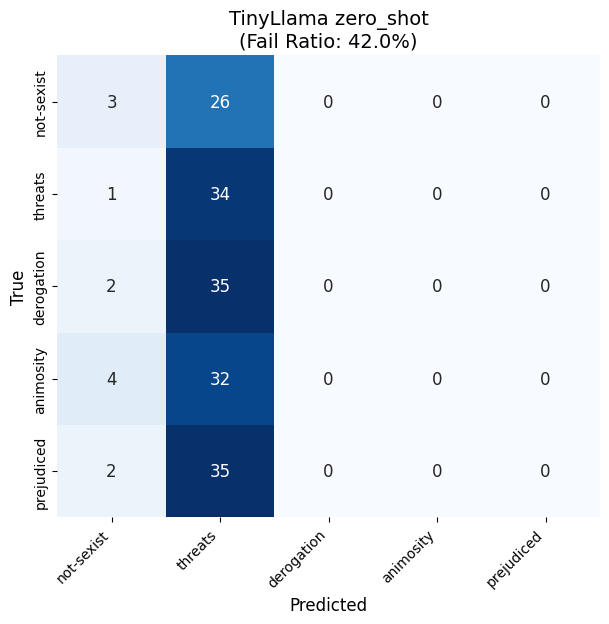

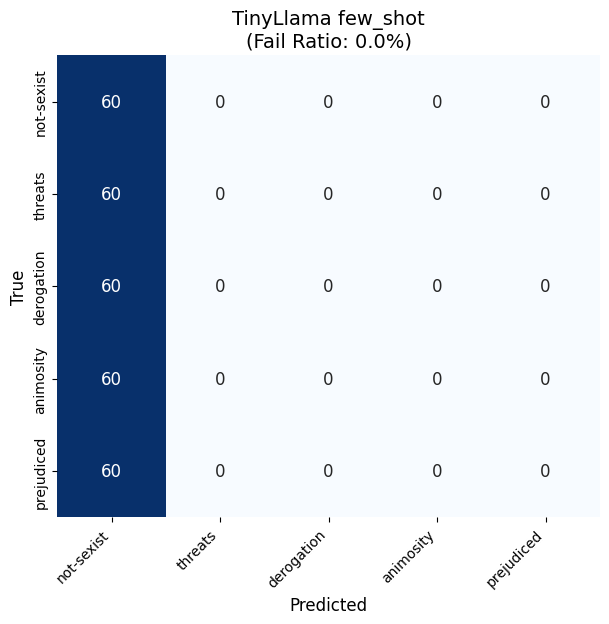

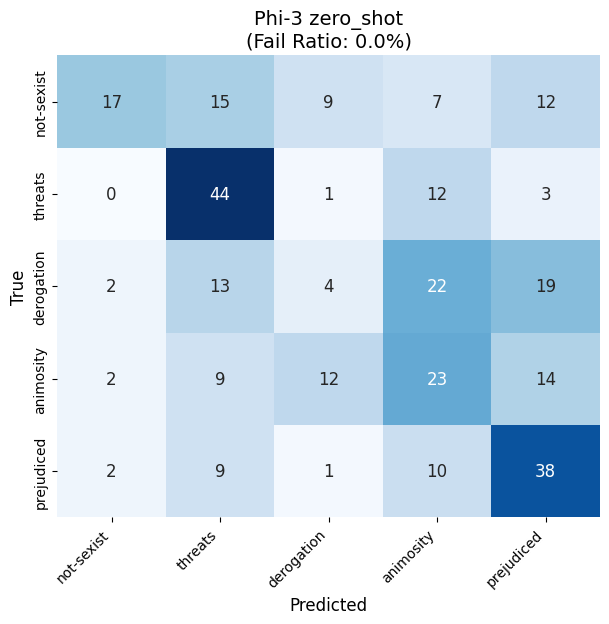

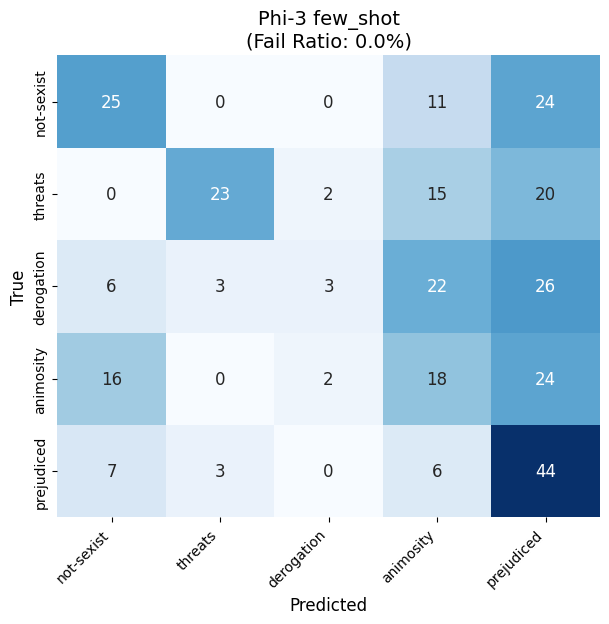

In [80]:
for model_name in metrics.keys():
  for model_task in model_results[model_name].keys():
    plot_cm(model_results[model_name][model_task], f"{model_name} {model_task}")

Observations on Generated Responses

1. Instruction Following & Hallucination (Zero-Shot)

TinyLlama (1.1B): The model struggled significantly with the zero-shot instructions. Instead of classifying the text, it frequently repeated the definitions provided in the system prompt (e.g., outputting "Sexist categories definitions: Threats..."). This resulted in a high Fail Ratio (42%) and very poor accuracy (~12%), as the model failed to generate a parseable label.

Phi-3 (3.8B): In contrast, Phi-3 demonstrated excellent instruction-following capabilities. It consistently generated valid, concise labels (e.g., "derogation", "prejudiced") without hallucinating definitions, achieving a 0% Fail Ratio and significantly higher accuracy (~42%).

2. Impact of Few-Shot Prompting

Format Correction: Few-shot prompting was critical for TinyLlama. Providing examples successfully "taught" the model the required output format (e.g., ANSWER: threats), causing the Fail Ratio to drop from 42% to 0%.

Performance: While few-shot prompting fixed the syntax errors for TinyLlama, its classification accuracy remained low (~20%), suggesting that while it could mimic the format, it still struggled to distinguish between the complex definitions of sexism compared to the more capable Phi-3.

3. Conclusion The experiment highlights that smaller models like TinyLlama require few-shot demonstrations to understand output constraints, whereas more capable models like Phi-3 can handle complex classification tasks effectively in a zero-shot setting.



"TinyLlama is an older/smaller architecture (1.1B) and lacks the strong instruction-following capabilities required for the complex definitions in Zero-shot."

"Phi-3 (3.8B), despite being small, has been trained on high-quality 'textbook quality' data, allowing it to understand the task without examples."

# [Task 7 - 1.0 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is not a copy-paste of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.

# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...

# FAQ

Please check this frequently asked questions before contacting us.

### Model cards

You can pick any open-source model card you like.

We recommend starting from those reported in this assignment.

### Implementation

Everything can be done via ``transformers`` APIs.

However, you are free to test frameworks, such as [LangChain](https://www.langchain.com/), [LlamaIndex](https://www.llamaindex.ai/) [LitParrot](https://github.com/awesome-software/lit-parrot), provided that you correctly address task instructions.

### Task Performance

The task is challenging and zero-shot prompting may show relatively low performance depending on the chosen model.

### Prompt Template

Do not change the provided prompt template.

You are only allowed to change it in case of a possible extension.

### Optimizations

Any kind of code optimization (e.g., speedup model inference or reduce computational cost) is more than welcome!

### Bonus Points

0.5 bonus points are arbitrarily assigned based on significant contributions such as:

- Outstanding error analysis
- Masterclass code organization
- Evaluate A1 dataset and perform comparison
- Perform prompt tuning

Note that bonus points are only assigned if all task points are attributed (i.e., 6/6).

# The End